In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import models,layers
import cv2
import os
import PIL

In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [ ]:
import pathlib
data_dir = pathlib.Path('/content/datasets/flower_photos/flower_photos')
data_dir

PosixPath('/content/datasets/flower_photos/flower_photos')

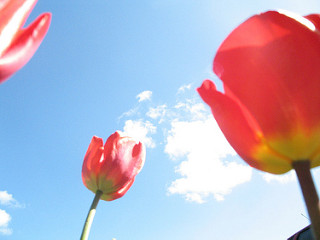

In [ ]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[1]))

In [ ]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [ ]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [ ]:
img = cv2.imread(flowers_images_dict['roses'][0])
img.shape

(276, 320, 3)

In [ ]:
x,y= [],[]
for flower_name,images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(image)
        resized_img = cv2.resize(img,(180,180))
        x.append(resized_img)
        y.append(flowers_labels_dict[flower_name])


In [ ]:
x = np.array(x)
y = np.array(y)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=0)

In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
num_classes = 5
model = models.Sequential([
          layers.Conv2D(16,3,padding='same',activation='relu'),
          layers.MaxPooling2D(),
          layers.Conv2D(32,3,padding='same',activation='relu'),
          layers.MaxPooling2D(),
          layers.Conv2D(64,3,padding='same',activation='relu'),
          layers.MaxPooling2D(),
          layers.Flatten(),
          layers.Dense(128,activation='relu'),
          layers.Dense(num_classes)
])
model.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

model.fit(x_train,y_train,epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.2087 - loss: 12.5028
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 84s 976ms/step - accuracy: 0.1994 - loss: 12.9045
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.2225 - loss: 12.5320
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 141s 989ms/step - accuracy: 0.2174 - loss: 12.6146
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 86s 999ms/step - accuracy: 0.2103 - loss: 12.7285


In [ ]:
model.evaluate(x_test,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.2294 - loss: 12.4213


[12.395835876464844, 0.23093682527542114]

In [ ]:
data_augmentation = keras.Sequential([
  layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ])

In [ ]:
num_classes = 5
model = models.Sequential([
          data_augmentation,
          layers.Conv2D(16,3,padding='same',activation='relu'),
          layers.MaxPooling2D(),
          layers.Conv2D(32,3,padding='same',activation='relu'),
          layers.MaxPooling2D(),
          layers.Conv2D(64,3,padding='same',activation='relu'),
          layers.MaxPooling2D(),
          layers.Dropout(0.2),
          layers.Flatten(),
          layers.Dense(128,activation='relu'),
          layers.Dense(num_classes)
])
model.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

model.fit(x_train,y_train,epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.2062 - loss: 2.4261
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.2008 - loss: 1.6094
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.2068 - loss: 1.6094
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.2053 - loss: 1.6094
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.1860 - loss: 1.6094


In [ ]:
model.evaluate(x_test,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 311ms/step - accuracy: 0.1588 - loss: 1.6094


[1.609437346458435, 0.16339869797229767]